In [40]:
# Airline Passenger Sentiment Analysis

# This project uses Natural Language Processing (NLP) and Machine Learning to classify airline passenger reviews into three sentiment categories:

#- Positive
#- Neutral
#- Negative

## Machine Learning Models
#- Logistic Regression
#- Linear Support Vector Machine (SVM)

## Technologies
#Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [41]:
## 1. Load Dataset

#The dataset contains airline passenger tweets/reviews along with their corresponding sentiment labels.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Tweets.csv to Tweets.csv


In [4]:
df = pd.read_csv("Tweets.csv")

In [5]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [6]:
df.shape

(14640, 15)

In [42]:
## 2. Dataset Exploration

In [7]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [9]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


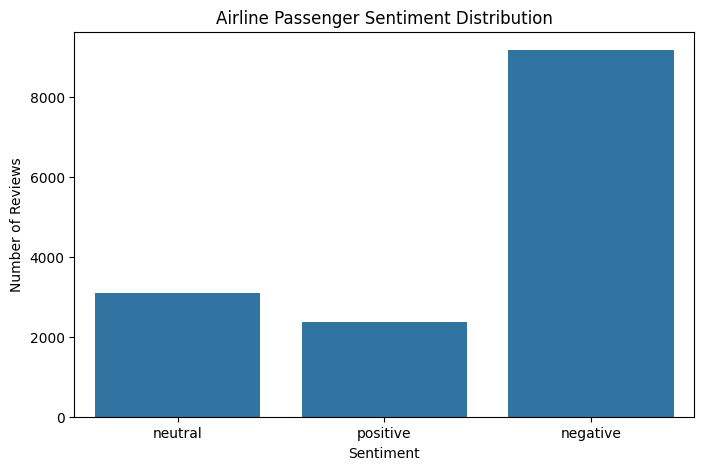

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="airline_sentiment"
)

plt.title("Airline Passenger Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [11]:
data = df[["text", "airline_sentiment"]].copy()

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="airline",
    hue="airline_sentiment"
)

plt.title("Sentiment Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

In [12]:
data.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [13]:
data.columns = ["review", "sentiment"]

In [14]:
data.head()

,review,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [15]:
data.isnull().sum()

,0
review,0
sentiment,0


In [46]:
## 3. Text Preprocessing

#The raw reviews contain usernames, URLs, punctuation, numbers, and unnecessary spaces.

#These elements are removed before converting the text into numerical features.

In [16]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions (@username)
    text = re.sub(r"@\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [17]:
data["cleaned_review"] = data["review"].apply(clean_text)

In [18]:
data[["review", "cleaned_review"]].head(10)

,review,cleaned_review
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this “ear worm”...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didnt…but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early youre...


In [47]:
## 4. TF-IDF Feature Extraction

#Machine learning models cannot directly process raw text.

#TF-IDF (Term Frequency-Inverse Document Frequency) converts the cleaned reviews into numerical feature vectors that can be used by the machine learning models.

In [48]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = tfidf.fit_transform(data["cleaned_review"])
y = data["sentiment"]

In [20]:
print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (14640, 5000)
Y shape: (14640,)


In [49]:
## 5. Train-Test Split

#The dataset is divided into:

#- 80% training data
#- 20% testing data

#Stratification is used to maintain the sentiment distribution in both sets.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11712, 5000)
Testing data: (2928, 5000)


In [50]:
## 6. Logistic Regression

#Logistic Regression is used as the first classification model for predicting whether a passenger review is positive, neutral, or negative.

In [23]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
y_pred_lr = logistic_model.predict(X_test)

In [25]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7646857923497268


In [26]:
print("Logistic Regression Accuracy:", round(accuracy_lr * 100, 2), "%")

Logistic Regression Accuracy: 76.47 %


In [27]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.78      0.94      0.86      1835
     neutral       0.62      0.42      0.50       620
    positive       0.82      0.53      0.64       473

    accuracy                           0.76      2928
   macro avg       0.74      0.63      0.67      2928
weighted avg       0.76      0.76      0.75      2928



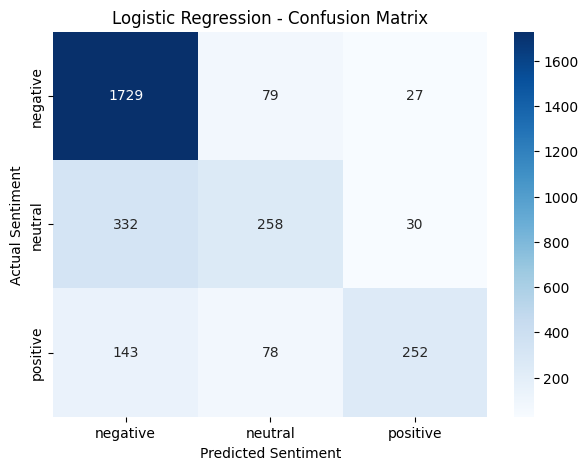

In [28]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [51]:
## 7. Linear Support Vector Machine

#A Linear SVM is used as the second classification model. Linear SVM is commonly used for text classification because it performs well with high-dimensional TF-IDF features.

In [29]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [30]:
y_pred_svm = svm_model.predict(X_test)

In [31]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(accuracy_svm * 100, 2), "%")

SVM Accuracy: 76.33 %


In [32]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.82      0.89      0.85      1835
     neutral       0.57      0.52      0.55       620
    positive       0.74      0.59      0.66       473

    accuracy                           0.76      2928
   macro avg       0.71      0.67      0.69      2928
weighted avg       0.76      0.76      0.76      2928



In [52]:
## 8. Model Comparison

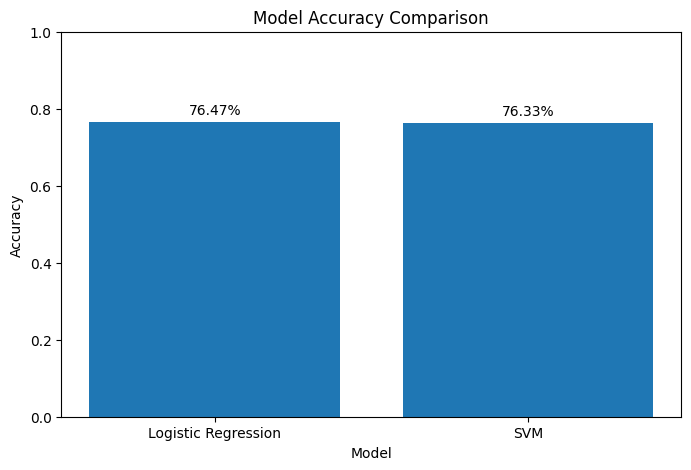

In [33]:
models = ["Logistic Regression", "SVM"]
accuracies = [accuracy_lr, accuracy_svm]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 0.02,
        f"{accuracy * 100:.2f}%",
        ha="center"
    )

plt.show()

In [53]:
## 9. Custom Sentiment Prediction

#The trained Logistic Regression model can be used to predict the sentiment of new airline passenger reviews.

In [34]:
def predict_sentiment(review):
    cleaned = clean_text(review)

    vectorized = tfidf.transform([cleaned])

    prediction = logistic_model.predict(vectorized)

    return prediction[0]

In [35]:
review = "The flight was amazing and the staff were very helpful."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: The flight was amazing and the staff were very helpful.
Predicted Sentiment: positive


In [36]:
review = "The flight was delayed for five hours and the service was terrible."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: The flight was delayed for five hours and the service was terrible.
Predicted Sentiment: negative


In [37]:
review = "The flight departed at 8 PM and arrived at 10 PM."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: The flight departed at 8 PM and arrived at 10 PM.
Predicted Sentiment: negative


In [54]:
## 10. Save Trained Models

#The trained TF-IDF vectorizer and machine learning models are saved using Joblib so they can be reused without retraining.

In [56]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

joblib.dump(
    logistic_model,
    "models/logistic_regression.pkl"
)

joblib.dump(
    svm_model,
    "models/svm.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [57]:
print(os.listdir("models"))

['svm.pkl', 'tfidf_vectorizer.pkl', 'logistic_regression.pkl']


In [58]:
loaded_tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

loaded_lr = joblib.load(
    "models/logistic_regression.pkl"
)

loaded_svm = joblib.load(
    "models/svm.pkl"
)

print("All saved models loaded successfully!")

All saved models loaded successfully!


In [59]:
review = "The flight was amazing and the staff were very helpful."

cleaned = clean_text(review)
vectorized = loaded_tfidf.transform([cleaned])

prediction = loaded_lr.predict(vectorized)

print("Review:", review)
print("Prediction:", prediction[0])

Review: The flight was amazing and the staff were very helpful.
Prediction: positive
